In [50]:
# Step 1: Import Libraries
import pandas as pd
import numpy as np
import sqlite3

In [31]:
# Step 2: Load CSV
df = pd.read_csv("student_performance.csv")
df.head()

,student_id,name,age,gender,department,semester,math_score,science_score,english_score,programming_score,attendance_percentage,city,admission_year
0,1001,Aarav Sharma,19,Male,Computer Science,2,85,78,72,91,92,Mumbai,2023
1,1002,Priya Patel,20,Female,Computer Science,2,76,82,88,79,87,Ahmedabad,2023
2,1003,Rohit Verma,19,Male,Electronics,2,65,74,61,55,78,Delhi,2023
3,1004,Sneha Reddy,20,Female,Mechanical,2,70,80,75,48,95,Hyderabad,2023
4,1005,Arjun Nair,19,Male,Computer Science,2,92,88,81,95,90,Kochi,2023


In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30 entries, 0 to 29
Data columns (total 13 columns):
 #   Column                 Non-Null Count  Dtype 
---  ------                 --------------  ----- 
 0   student_id             30 non-null     int64 
 1   name                   30 non-null     object
 2   age                    30 non-null     int64 
 3   gender                 30 non-null     object
 4   department             30 non-null     object
 5   semester               30 non-null     int64 
 6   math_score             30 non-null     int64 
 7   science_score          30 non-null     int64 
 8   english_score          30 non-null     int64 
 9   programming_score      30 non-null     int64 
 10  attendance_percentage  30 non-null     int64 
 11  city                   30 non-null     object
 12  admission_year         30 non-null     int64 
dtypes: int64(9), object(4)
memory usage: 3.2+ KB


In [9]:
df.describe()

,student_id,age,semester,math_score,science_score,english_score,programming_score,attendance_percentage,admission_year
count,30.000000,30.000000,30.0,30.000000,30.000000,30.000000,30.000000,30.000000,30.0
mean,1015.500000,19.733333,2.0,76.066667,77.833333,74.166667,67.600000,84.500000,2023.0
std,8.803408,0.739680,0.0,11.467896,8.554423,10.003735,21.041175,9.379913,0.0
min,1001.000000,19.000000,2.0,56.000000,61.000000,55.000000,38.000000,65.000000,2023.0
25%,1008.250000,19.000000,2.0,67.250000,71.250000,67.250000,49.250000,77.250000,2023.0
50%,1015.500000,20.000000,2.0,75.500000,78.000000,75.000000,66.000000,86.500000,2023.0
75%,1022.750000,20.000000,2.0,85.750000,83.750000,81.750000,88.750000,91.750000,2023.0
max,1030.000000,21.000000,2.0,95.000000,93.000000,90.000000,97.000000,98.000000,2023.0


In [10]:
df.isnull().sum()

,0
student_id,0
name,0
age,0
gender,0
department,0
semester,0
math_score,0
science_score,0
english_score,0
programming_score,0


In [32]:
# Step 3: Store Data in SQLite
conn = sqlite3.connect("student.db")

df.to_sql(
    "students",
    conn,
    if_exists="replace",
    index=False
)

print("Data stored successfully")

Data stored successfully


In [35]:
# Step 4: Five SQL Analysis Queries
# Average Programming Score
query1 = """
SELECT AVG(Programming_Score)
AS Avg_Programming_Score
FROM students;
"""

print(pd.read_sql(query1, conn))

   Avg_Programming_Score
0                   67.6


In [36]:
# Department-wise Average Score
query2 = """
SELECT Department,
AVG(Programming_Score) AS Avg_Score
FROM students
GROUP BY Department;
"""

print(pd.read_sql(query2, conn))

         department  Avg_Score
0             Civil  40.600000
1  Computer Science  89.230769
2       Electronics  61.500000
3        Mechanical  49.333333


In [39]:
# Top 5 Students
query3 = """
SELECT Name,
Programming_Score
FROM students
ORDER BY Programming_Score DESC
LIMIT 5;
"""

print(pd.read_sql(query3, conn))

             name  programming_score
0      Ananya Das                 97
1     Tanvi Mehta                 96
2      Arjun Nair                 95
3  Akanksha Yadav                 94
4     Divya Singh                 93


In [40]:
# Students Above 90 Marks
query5 = """
SELECT COUNT(*) AS High_Performers
FROM students
WHERE Programming_Score > 90;
"""

print(pd.read_sql(query5, conn))

   High_Performers
0                7


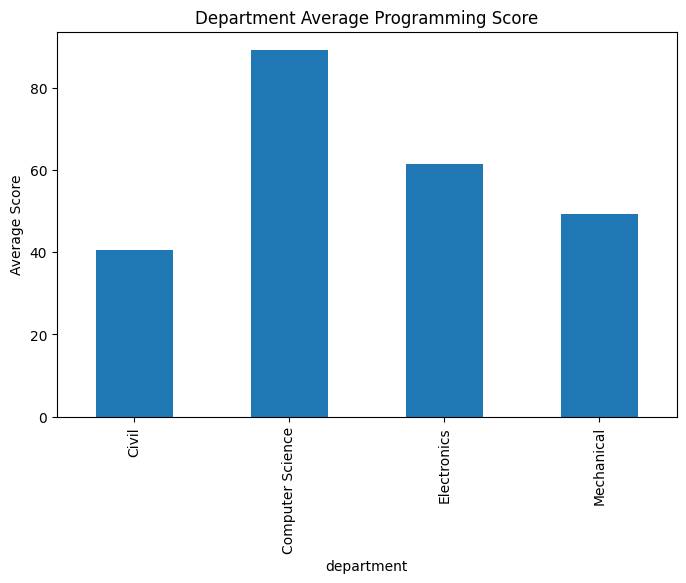

In [49]:
# Step 5: Visualization
# Department Average Score

import matplotlib.pyplot as plt
import seaborn as sns

dept_avg = df.groupby("department")["programming_score"].mean()

dept_avg.plot(
    kind="bar",
    figsize=(8,5)
)

plt.title("Department Average Programming Score")
plt.ylabel("Average Score")
plt.show()

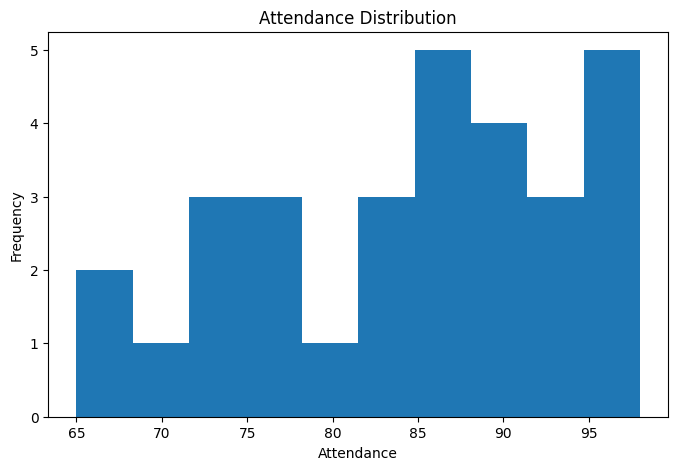

In [43]:
# Attendance Distribution
plt.figure(figsize=(8,5))

plt.hist(
    df["attendance_percentage"],
    bins=10
)

plt.title("Attendance Distribution")
plt.xlabel("Attendance")
plt.ylabel("Frequency")

plt.show()

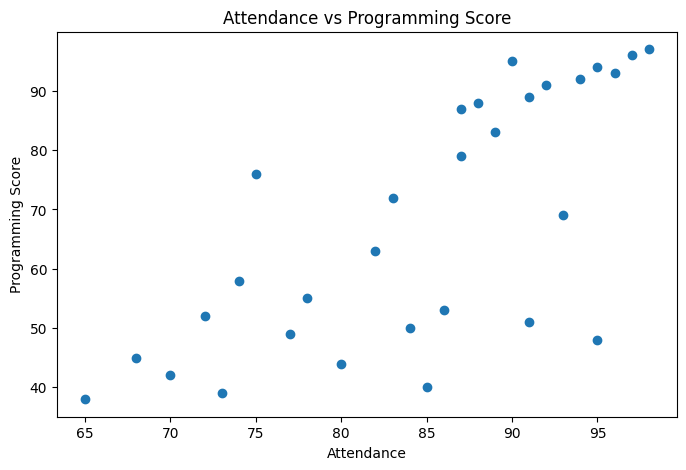

In [44]:
# Attendance vs Programming Score
plt.figure(figsize=(8,5))

plt.scatter(
    df["attendance_percentage"],
    df["programming_score"]
)

plt.xlabel("Attendance")
plt.ylabel("Programming Score")

plt.title("Attendance vs Programming Score")

plt.show()

In [51]:
# Step 6: Machine Learnin
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, r2_score

X = df.drop(
    columns=["programming_score"]
)

X = pd.get_dummies(
    X,
    drop_first=True
)

y = df["programming_score"]

In [46]:
# Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [26]:
model = RandomForestRegressor(random_state=42)
model.fit(X_train, y_train)

pred = model.predict(X_test)

print("MAE:",
      mean_absolute_error(y_test, pred))

print("R2 Score:",
      r2_score(y_test, pred))

MAE: 3.9299999999999997
R2 Score: 0.954853693673572


In [47]:
# Train Model

new_student = X_test.iloc[[0]]

prediction = model.predict(new_student)

print(
    "Predicted Programming Score:",
    prediction[0]
)

Predicted Programming Score: 46.69


In [48]:
# Step 7: Business Summary Report
print("\n===== BUSINESS INSIGHTS ====")

print(
    f"Average Programming Score: "
    f"{df['programming_score'].mean():.2f}"
)

print(
    f"Average Attendance: "
    f"{df['attendance_percentage'].mean():.2f}%"
)

best_dept = df.groupby(
    "department"
)["programming_score"].mean().idxmax()

print(
    f"Best Performing Department: "
    f"{best_dept}"
)

high_performers = len(
    df[df["programming_score"] > 90]
)

print(
    f"Students scoring above 90: "
    f"{high_performers}"
)


===== BUSINESS INSIGHTS ====
Average Programming Score: 67.60
Average Attendance: 84.50%
Best Performing Department: Computer Science
Students scoring above 90: 7
